# slimfarmer tutorial

End-to-end photometry on a Roman IMCOM CPR image.

**Steps**
1. Prepare images from the CPR file (science, weight, PSF)
2. Run slimfarmer
3. Inspect catalog
4. Validate photometry against the truth catalog
5. Diagnose individual sources

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.wcs import WCS
import astropy.units as u
from scipy.stats import binned_statistic
import sys
sys.path.insert(0, "../../")
import slimfarmer
from slimfarmer.track import _get_flux_converters

print(f'slimfarmer {slimfarmer.__version__}')

slimfarmer 1.0.0


## 1. Prepare images from CPR

`prepare_images_from_cpr` reads an IMCOM compressed output file and writes three FITS files:
- **science image** — layer 0 of the CPR cube (background-subtracted DN/px/s)
- **weight map** — inverse-variance, combining correlated reconstruction noise and Poisson noise
- **PSF stamp** — 2-D Gaussian at the Roman H158 effective FWHM, normalised to sum=1

In [2]:
CPR_PATH = '/home/chto/code/Roman/data/openUV24/im3x2-H0_00_00.cpr.fits.gz'
WORK_DIR = '/home/chto/code/Roman/data/openUV24/output_slimfarmer/'

sci_path, wht_path, psf_path = slimfarmer.prepare_images_from_cpr(
    cpr_path = CPR_PATH,
    work_dir = WORK_DIR,
    # psf_fwhm_arcsec=0.240,  # override if needed
)
print(f'sci: {sci_path}')
print(f'wht: {wht_path}')
print(f'psf: {psf_path}')

sci: /home/chto/code/Roman/data/openUV24/output_slimfarmer/roman_image.fits
wht: /home/chto/code/Roman/data/openUV24/output_slimfarmer/roman_weight.fits
psf: /home/chto/code/Roman/data/openUV24/output_slimfarmer/PSF_F158.fits


Image shape : (2108, 2108)
Pixel scale : 0.04902 arcsec/px
Science range: -7.548 – 1282.031
Weight range : 1.935e-01 – 6.693e+03


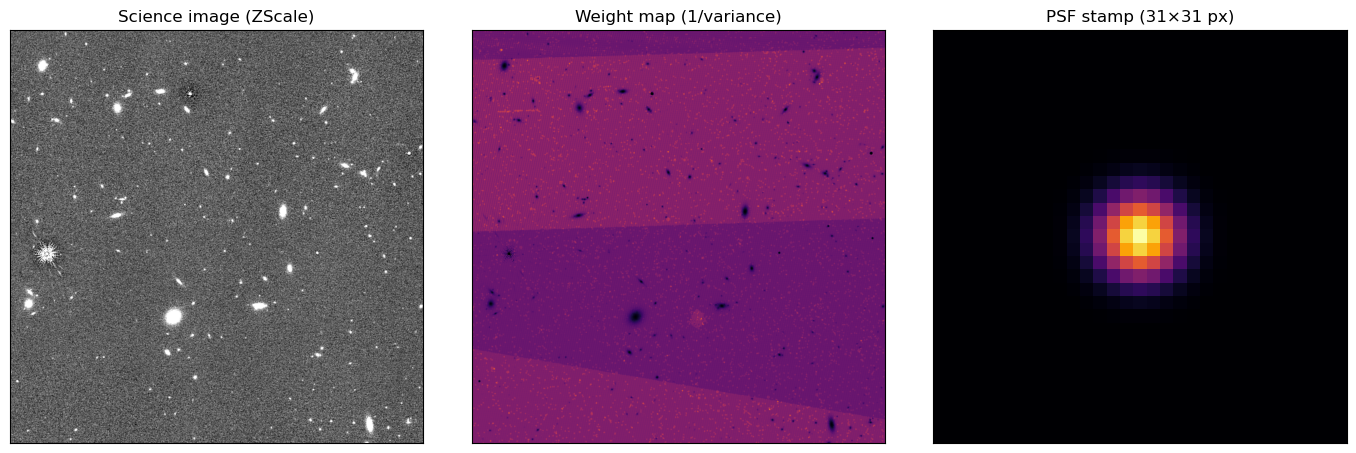

In [3]:
# Preview science image and weight map
sci = fits.getdata(sci_path).astype(float)
wht = fits.getdata(wht_path).astype(float)
psf = fits.getdata(psf_path).astype(float)

with fits.open(sci_path) as h:
    pix_scale = abs(h[0].header['CDELT2']) * 3600.
print(f'Image shape : {sci.shape}')
print(f'Pixel scale : {pix_scale:.5f} arcsec/px')
print(f'Science range: {sci.min():.3f} – {sci.max():.3f}')
print(f'Weight range : {wht.min():.3e} – {wht.max():.3e}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

norm = ImageNormalize(sci, interval=ZScaleInterval())
axes[0].imshow(sci, origin='lower', cmap='gray', norm=norm)
axes[0].set_title('Science image (ZScale)')

axes[1].imshow(wht, origin='lower', cmap='inferno')
axes[1].set_title('Weight map (1/variance)')

axes[2].imshow(psf, origin='lower', cmap='inferno')
axes[2].set_title(f'PSF stamp ({psf.shape[0]}×{psf.shape[1]} px)')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 2. Run slimfarmer

In [32]:
import galsim, galsim.roman as groman

bp        = galsim.roman.getBandpasses()
BAND      = 'F158'
ZEROPOINT = bp['H158'].zeropoint + 2.5 * np.log10(groman.collecting_area)
print(f'Zeropoint: {ZEROPOINT:.6f}')

cat = slimfarmer.run_photometry(
    science_path = sci_path,
    weight_path  = wht_path,
    psf_path     = psf_path,
    band         = BAND,
    zeropoint    = ZEROPOINT,
    output_path  = WORK_DIR + '/catalog.fits',
    ncpus        = 48,   # set >0 on a cluster
    neighbor_subtraction = False
)
print(f'\n{len(cat)} sources detected')

[22:58:02] slimfarmer :: INFO - Loading F158 from /home/chto/code/Roman/data/openUV24/output_slimfarmer/roman_image.fits
[22:58:02] slimfarmer :: INFO - Running SEP source detection...


Zeropoint: 26.511268


[22:58:02] slimfarmer :: INFO - Detected 517 sources.
[22:58:02] slimfarmer :: INFO - Grouping with dilation radius 0.07" = 1 px
[22:58:02] slimfarmer :: INFO - Found 480 groups.
[22:58:02] slimfarmer :: INFO - Processing 480 groups (ncpus=48)...
Groups: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 480/480 [01:19<00:00,  6.03it/s]
[22:59:23] slimfarmer :: INFO - Finished — 499 sources fit.



517 sources detected


## 3. Inspect catalog

In [33]:
# Model type breakdown
from collections import Counter
names = [n.decode() if isinstance(n, bytes) else str(n) for n in cat['name']]
print('Model type counts:')
for model, count in Counter(names).most_common():
    print(f'  {model:30s} {count:4d}')

Model type counts:
  PointSource                     161
  DevGalaxy                       139
  FixedCompositeGalaxy             93
  ExpGalaxy                        91
  Bad                              27
  SimpleGalaxy                      6


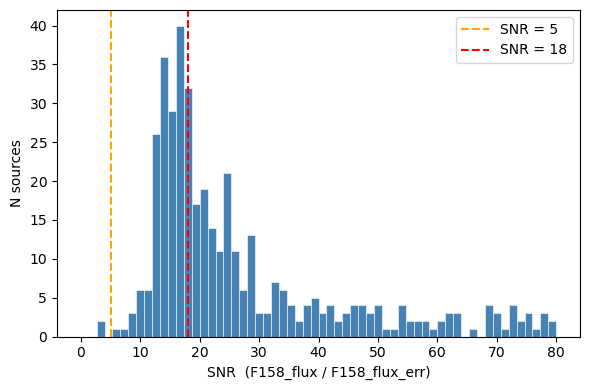

SNR > 5:  476
SNR > 18: 311


In [34]:
# SNR distribution
snr = np.array(cat[f'{BAND}_flux'], dtype=float) / np.array(cat[f'{BAND}_flux_err'], dtype=float)
finite = np.isfinite(snr) & (snr > 0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(snr[finite], bins=60, range=(0, 80), color='steelblue', edgecolor='white', lw=0.4)
ax.axvline(5,  color='orange', ls='--', lw=1.5, label='SNR = 5')
ax.axvline(18, color='red',    ls='--', lw=1.5, label='SNR = 18')
ax.set_xlabel(f'SNR  ({BAND}_flux / {BAND}_flux_err)')
ax.set_ylabel('N sources')
ax.legend()
plt.tight_layout(); plt.show()
print(f'SNR > 5:  {(snr[finite] > 5).sum()}')
print(f'SNR > 18: {(snr[finite] > 18).sum()}')

 id
---
249


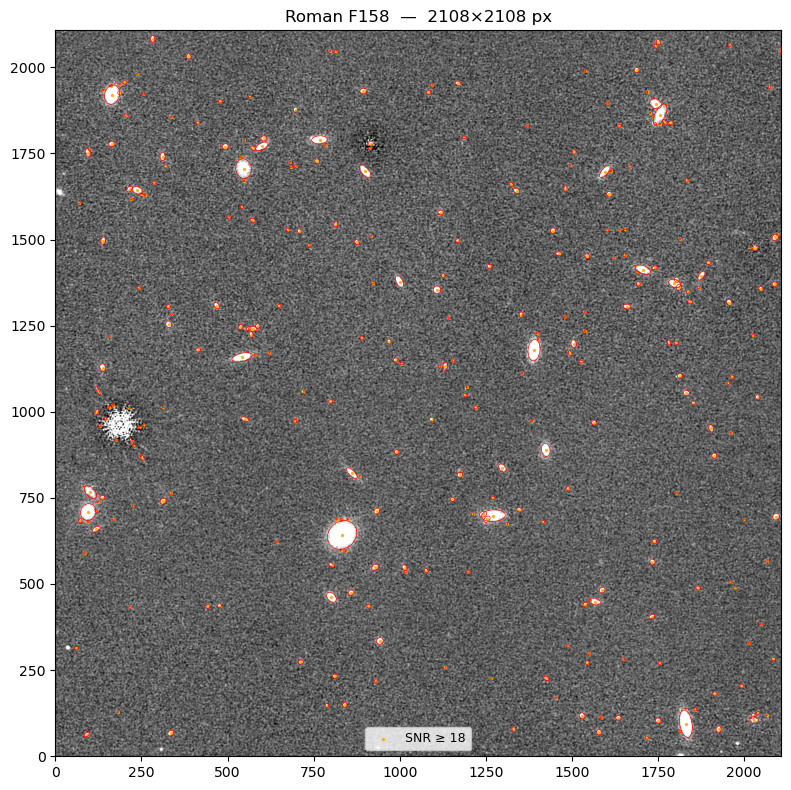

In [40]:
# Source positions overlaid on the science image
wcs_img = WCS(fits.getheader(sci_path))
x_all, y_all = wcs_img.world_to_pixel_values(cat['ra'], cat['dec'])
high_snr = snr > 18

norm = ImageNormalize(sci, interval=ZScaleInterval())
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(sci, origin='lower', cmap='gray', norm=norm)
ax.scatter(x_all[high_snr], y_all[high_snr], s=2, c='orange', alpha=0.8, label='SNR ≥ 18')
for i in np.where(high_snr)[0]:
    e = Ellipse(xy=(x_all[i], y_all[i]),
                width=6*float(cat['a'][i]), height=6*float(cat['b'][i]),
                angle=float(cat['theta'][i]) * 180. / np.pi)
    e.set_facecolor('none'); e.set_edgecolor('red'); e.set_linewidth(0.5)
    ax.add_artist(e)
ax.legend(fontsize=9)
ax.set_title(f'Roman {BAND}  —  {sci.shape[1]}×{sci.shape[0]} px')
#plt.xlim(1350, 1450)
#plt.ylim(1140, 1250)
print(cat['id'][np.where((x_all>1350)&(x_all<1450)&(1140<y_all)&(y_all<1200))])
plt.tight_layout(); plt.show()

## 4. Validate photometry against the truth catalog

In [37]:
DATA="/project/kicp/chto/Roman/openUV24/"

In [38]:
truth = (pd.read_parquet(DATA + '/galaxy_flux_10307.parquet')
           .merge(pd.read_parquet(DATA + '/galaxy_10307.parquet'), on='galaxy_id'))

obs_to_nm, truth_to_nm = _get_flux_converters(sci_path, BAND)

cat_c  = SkyCoord(cat['ra'], cat['dec'], unit='deg')
tru_c  = SkyCoord(truth['ra'].values, truth['dec'].values, unit='deg')
idx, d2d, _ = cat_c.match_to_catalog_sky(tru_c)
sep_as = d2d.to(u.arcsec).value

flux_obs  = np.array([obs_to_nm(float(f)) for f in cat[f'{BAND}_flux']])
flux_true = np.array([truth_to_nm(float(truth['roman_flux_H158'].iloc[i])) for i in idx])
src_names = np.array([n.decode() if isinstance(n, bytes) else str(n) for n in cat['name']])

good  = ((sep_as < 0.2) & (snr > 18) & (flux_true > 0)
         & np.isfinite(flux_obs) & (src_names != 'PointSource'))
ratio = flux_obs[good] / flux_true[good]

print(f'Matched {good.sum()} high-quality galaxies (sep<0.2", SNR>18, non-PS)')
print(f'  median ratio : {np.median(ratio):.4f}')
print(f'  16/84 pctile : {np.percentile(ratio,16):.4f} / {np.percentile(ratio,84):.4f}')
print(f'  NMAD         : {1.4826*np.median(np.abs(ratio-np.median(ratio))):.4f}')

Matched 214 high-quality galaxies (sep<0.2", SNR>18, non-PS)
  median ratio : 0.9677
  16/84 pctile : 0.8243 / 1.2243
  NMAD         : 0.1709


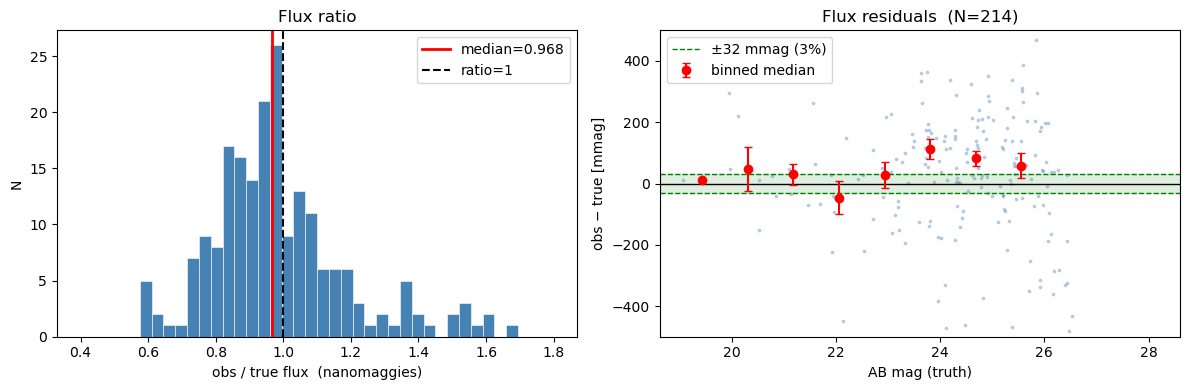

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Flux ratio histogram
axes[0].hist(ratio, bins=40, range=(0.4, 1.8), color='steelblue', edgecolor='white', lw=0.4)
axes[0].axvline(np.median(ratio), color='red',   lw=2,   label=f'median={np.median(ratio):.3f}')
axes[0].axvline(1.0,              color='black', lw=1.5, ls='--', label='ratio=1')
axes[0].set_xlabel('obs / true flux  (nanomaggies)')
axes[0].set_ylabel('N'); axes[0].legend()
axes[0].set_title('Flux ratio')

# Residuals vs magnitude
mag_true = 22.5 - 2.5 * np.log10(flux_true[good] + 1e-30)
resid    = -2.5 * np.log10(ratio) * 1000   # mmag

magbins   = np.linspace(19, 26, 9)
midpoints = 0.5 * (magbins[:-1] + magbins[1:])
med_r, _, _ = binned_statistic(mag_true, resid, bins=magbins, statistic=np.nanmedian)
std_r, _, _ = binned_statistic(mag_true, resid, bins=magbins, statistic=np.nanstd)
cnt_r, _, _ = binned_statistic(mag_true, resid, bins=magbins, statistic='count')

axes[1].axhspan(-32, 32, alpha=0.12, color='green')
axes[1].axhline(0,   color='black', lw=1)
axes[1].axhline(-32, color='green', lw=1, ls='--', label='±32 mmag (3%)')
axes[1].axhline( 32, color='green', lw=1, ls='--')
axes[1].scatter(mag_true, resid, s=3, alpha=0.3, color='steelblue')
axes[1].errorbar(midpoints, med_r,
                 yerr=std_r / np.sqrt(np.maximum(cnt_r, 1)),
                 fmt='o', color='red', capsize=3, label='binned median')
axes[1].set_xlabel('AB mag (truth)'); axes[1].set_ylabel('obs − true [mmag]')
axes[1].set_ylim(-500, 500); axes[1].legend()
axes[1].set_title(f'Flux residuals  (N={good.sum()})')

plt.tight_layout(); plt.show()

## 5. Diagnose individual sources

Build a `FarmerImage` once — it can be reused for any number of `diagnose_source` calls.

In [ ]:
with fits.open(sci_path) as h:
    oversamplepix = abs(h[0].header['CDELT2']) * 3600.

img = slimfarmer.FarmerImage(
    bands={BAND: {
        'science':   sci_path,
        'weight':    wht_path,
        'psf':       psf_path,
        'zeropoint': ZEROPOINT,
    }},
    detection_band=BAND,
)
img.detect()
print(f'{len(img.catalog)} sources')

In [12]:
# Pick a source to inspect — e.g. a bright galaxy with SNR>18
candidates = cat[(snr > 30) & (src_names != 'PointSource')]
print('High-SNR galaxy candidates:')
print(candidates['id', 'F158_mag', 'name', 'total_rchisq'][:10])

High-SNR galaxy candidates:
 id      F158_mag              name            total_rchisq   
--- ------------------ -------------------- ------------------
 15  23.36322576264029            DevGalaxy 0.7964556443060918
 16 23.581640742200282            ExpGalaxy 1.4616692158358935
 18 22.538251373778667 FixedCompositeGalaxy 0.5818216061950059
 20  22.90304043381593            ExpGalaxy  1.144643477669996
 21 23.815330158713344            ExpGalaxy 0.6097221345920224
 22  22.62711029569411            ExpGalaxy 1.1277765866900518
 25 22.492921498375544            DevGalaxy 0.6252448865893482
 27  22.70802440484905 FixedCompositeGalaxy 0.2910475308360571
 30  22.12211291131785            DevGalaxy 1.9787835712917443
 31 21.837160121995947 FixedCompositeGalaxy 2.0335594055941595


=== Source 249 ===
  x=1389.98  y=1178.81  ra=10.2907373  dec=-43.5264661
  SEP a=0.512"  b=0.285"  group_id=205  pop=2
  segmap pixels=2089  segmap sum=1273.92 DN → 9.16956 nMgy

  Circular aperture sums:
    r=0.1" (2.0px): 105.84 DN → 0.76183 nMgy
    r=0.2" (4.1px): 331.42 DN → 2.38554 nMgy
    r=0.3" (6.1px): 528.18 DN → 3.80176 nMgy
    r=0.5" (10.2px): 811.69 DN → 5.84248 nMgy
    r=0.7" (14.3px): 991.75 DN → 7.13847 nMgy
    r=1.0" (20.4px): 1157.80 DN → 8.33373 nMgy
    r=1.5" (30.6px): 1285.01 DN → 9.24938 nMgy

  Truth galaxies within 5":
    sep=0.009"  gal_id=10307000251953  flux=10.52208 nMgy  dhlr=0.506"
    sep=1.760"  gal_id=10307100377511  flux=0.01768 nMgy  dhlr=0.103"
    sep=2.879"  gal_id=10307101545910  flux=0.00295 nMgy  dhlr=0.027"
    sep=3.085"  gal_id=10307101431111  flux=0.00284 nMgy  dhlr=0.048"
    sep=3.440"  gal_id=10307101431112  flux=0.00266 nMgy  dhlr=0.038"
    sep=3.658"  gal_id=10307101431110  flux=0.02595 nMgy  dhlr=0.072"

  Tractor model: ExpGa

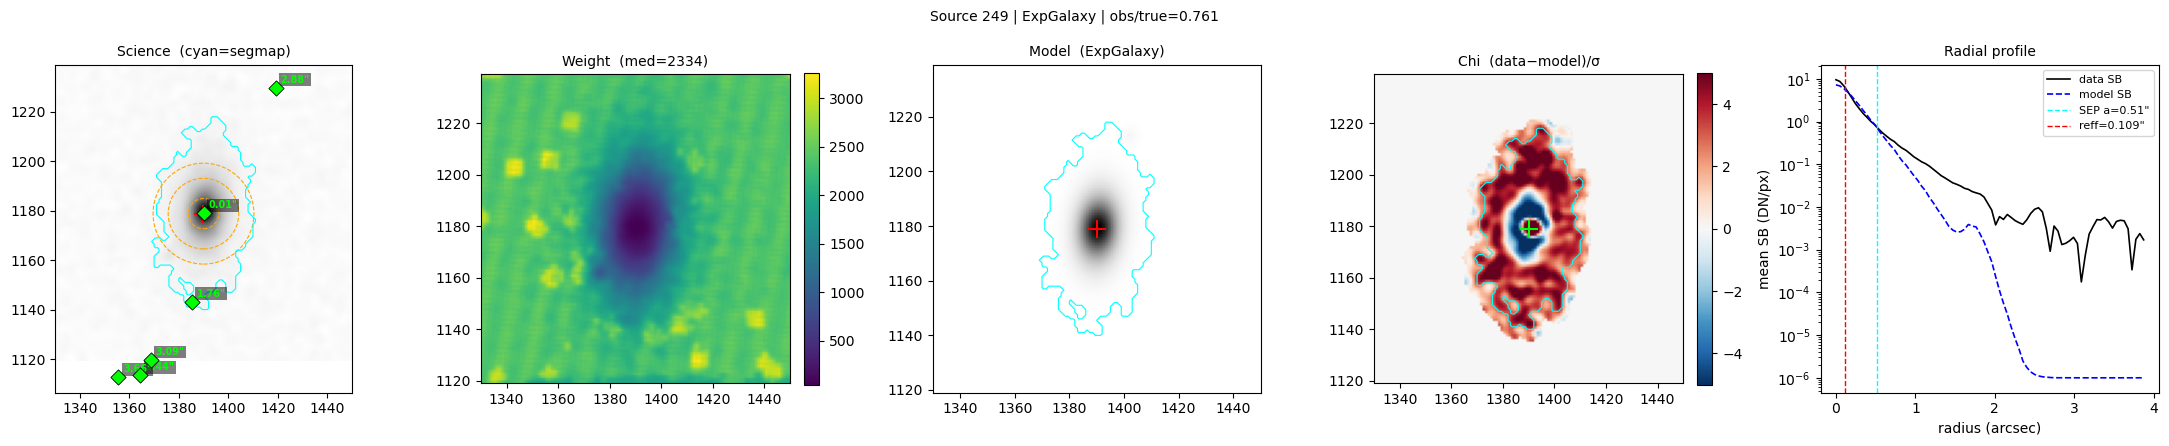

In [29]:
# Diagnose a specific source
SOURCE_ID = 249#int(candidates['id'][1])   # change to any id

result = slimfarmer.diagnose_source(
    SOURCE_ID, img, truth, obs_to_nm, truth_to_nm, oversamplepix,
    band=BAND, truth_flux_col='roman_flux_H158',
)
plt.show()

In [30]:
print(f"Model   : {result['model_name']}")
print(f"obs_flux: {result['obs_nm']:.5f} nMgy")
print(f"true_flux: {result['true_nm']:.5f} nMgy")
print(f"obs/true: {result['ratio']:.4f}")
print(f"rchisq  : {result['rchisq']:.4f}")
if not np.isnan(result['reff']):
    print(f"reff    : {result['reff']:.4f} arcsec")

Model   : ExpGalaxy
obs_flux: 8.01187 nMgy
true_flux: 10.52208 nMgy
obs/true: 0.7614
rchisq  : 19.2997
reff    : 0.1091 arcsec


### Track model selection stages for any source

[22:42:18] slimfarmer :: INFO - Loading F158 from /home/chto/code/Roman/data/openUV24/output_slimfarmer/roman_image.fits
[22:42:18] slimfarmer :: INFO - Running SEP source detection...
[22:42:19] slimfarmer :: INFO - Detected 517 sources.
[22:42:19] slimfarmer :: INFO - Grouping with dilation radius 0.07" = 1 px
[22:42:19] slimfarmer :: INFO - Found 480 groups.


Source 249  |  group_id=205  group_pop=2
Position: x=1389.98  y=1178.81  ra=10.290737  dec=-43.526466

Truth matches within 10.0":
  galaxy_id=10307000251953  ra=10.290735  dec=-43.526464  sep=0.009"  flux=10.5221 nMgy
  galaxy_id=10307100377511  ra=10.290831  dec=-43.526950  sep=1.760"  flux=0.0177 nMgy
  galaxy_id=10307101545910  ra=10.290180  dec=-43.525776  sep=2.879"  flux=0.0030 nMgy
  galaxy_id=10307101431111  ra=10.291148  dec=-43.527270  sep=3.085"  flux=0.0028 nMgy
  galaxy_id=10307101431112  ra=10.291227  dec=-43.527353  sep=3.440"  flux=0.0027 nMgy
  galaxy_id=10307101431110  ra=10.291398  dec=-43.527362  sep=3.658"  flux=0.0260 nMgy
  galaxy_id=10307200516076  ra=10.289326  dec=-43.526466  sep=3.685"  flux=0.0008 nMgy
  galaxy_id=10307200516078  ra=10.289210  dec=-43.526589  sep=4.011"  flux=0.0009 nMgy
  galaxy_id=10307201165118  ra=10.291561  dec=-43.527636  sep=4.728"  flux=0.0024 nMgy
  galaxy_id=10307101616859  ra=10.291391  dec=-43.525224  sep=4.787"  flux=0.0049 nMg

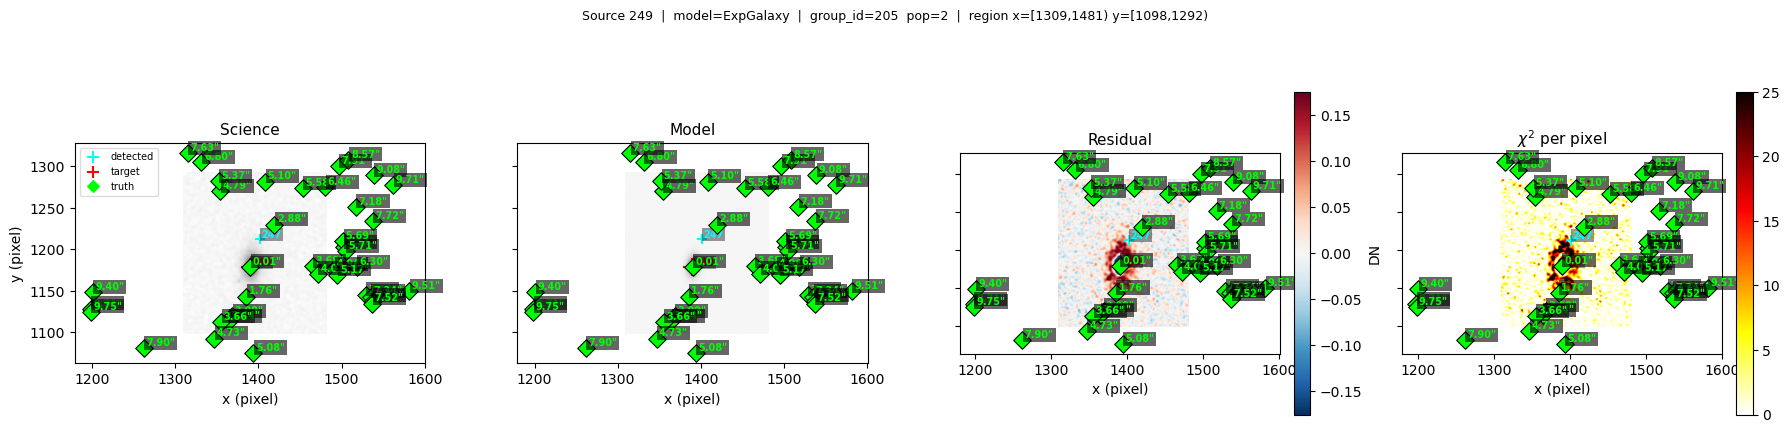

In [31]:
from slimfarmer.track import track_source

result_track = track_source(
    source_id       = SOURCE_ID,
    science_path    = sci_path,
    weight_path     = wht_path,
    psf_path        = psf_path,
    band            = BAND,
    zeropoint       = ZEROPOINT,
    truth_pos_path  = DATA + '/galaxy_10307.parquet',
    truth_flux_path = DATA + '/galaxy_flux_10307.parquet',
    truth_flux_col  = 'roman_flux_H158',
    plot            = True,
)
plt.show()